First, we need to import the OpenCV library (`cv2`). If you don't have it installed, you can install it using `pip`.

In [1]:
import cv2
import numpy as np

# Install opencv-python if not already installed
# !pip install opencv-python

Now, here's the Python function `subtract_background_by_color` that takes an image path and optional `lower_bound` and `upper_bound` for the background color in HSV. It will load the image, convert it to HSV, create a mask for the specified color range, and then apply the mask to remove the background, returning the image with the background removed.

### How it works:
1.  **Load Image**: Reads the image from the given `image_path`.
2.  **Convert to HSV**: Converts the image from BGR (OpenCV's default) to HSV color space. HSV is often better for color-based segmentation than BGR because it separates color information (Hue) from intensity (Value).
3.  **Define Color Range**: Uses `lower_bound` and `upper_bound` to define the range of the background color in HSV. By default, it's set to a common range for a light blue/sky background.
4.  **Create Mask**: `cv2.inRange` creates a binary mask where pixels within the specified HSV color range are white (255) and others are black (0).
5.  **Invert Mask**: The mask is inverted so that the background becomes black and the foreground (non-background) becomes white.
6.  **Apply Mask**: The inverted mask is applied to the original image using `cv2.bitwise_and`. This operation keeps only the pixels from the original image where the mask is white, effectively removing the masked (background) areas.

In [2]:
def subtract_background_by_color(image_path, lower_bound=None, upper_bound=None):
    """
    Subtracts the background of an image based on a specified color range.

    Args:
        image_path (str): The path to the input image.
        lower_bound (tuple): A tuple (H, S, V) representing the lower bound of the
                             background color in HSV. If None, a default light blue is used.
        upper_bound (tuple): A tuple (H, S, V) representing the upper bound of the
                             background color in HSV. If None, a default light blue is used.

    Returns:
        numpy.ndarray: The image with the background removed, or None if the image could not be loaded.
    """
    # Load the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Convert the image to HSV color space
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define the default range for a light blue background (e.g., sky)
    # You might need to adjust these values based on your specific background color
    if lower_bound is None:
        # Default for a light blue/sky color
        lower_bound = np.array([90, 50, 50])
    if upper_bound is None:
        # Default for a light blue/sky color
        upper_bound = np.array([130, 255, 255])

    # Create a mask to detect the background color
    mask = cv2.inRange(hsv, lower_bound, upper_bound)

    # Invert the mask to get the foreground (non-background)
    mask_inv = cv2.bitwise_not(mask)

    # Apply the inverted mask to the original image
    # This keeps only the foreground and makes the background black
    background_subtracted_img = cv2.bitwise_and(img, img, mask=mask_inv)

    return background_subtracted_img

You can now use this function. For example, to apply it to the `/content/image.jpg` file and display the result:

Original Image:


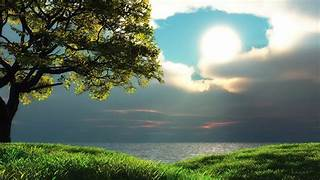


Image with Background Subtracted:


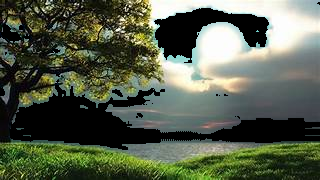

In [3]:
# Example usage:
from google.colab.patches import cv2_imshow

input_image_path = '/content/image.jpg'

# Subtract background using default color range (light blue)
result_image = subtract_background_by_color(input_image_path)

if result_image is not None:
    print("Original Image:")
    original_image = cv2.imread(input_image_path)
    cv2_imshow(original_image)

    print("\nImage with Background Subtracted:")
    cv2_imshow(result_image)

    # If you want to save the result:
    # cv2.imwrite('image_no_background.jpg', result_image)

# --- Advanced Usage: Specify a custom color range (e.g., for green screen) ---
# Define a green color range in HSV (adjust these values for your specific green shade)
# For a common green screen:
# lower_green = np.array([35, 100, 100])
# upper_green = np.array([85, 255, 255])

# # Subtract background using the custom green color range
# result_green_screen = subtract_background_by_color(input_image_path, lower_bound=lower_green, upper_bound=upper_green)

# if result_green_screen is not None:
#     print("\nImage with Green Background Subtracted:")
#     cv2_imshow(result_green_screen)
